# Retail Store Sales — Data Cleaning & Exploratory Data Analysis

**Author:** Data Analyst Portfolio Project  
**Dataset:** Retail Store Sales (Dirty) — Kaggle  
**Tools:** Python · pandas · numpy · matplotlib · seaborn

---
## 1. Introduction

This project demonstrates a complete data cleaning pipeline applied to a deliberately messy retail sales dataset.
The dataset contains **12,575 transactions** across **11 columns** spanning January 2022 to January 2025,
covering 8 product categories, 3 payment methods, and 2 sales channels (Online / In-store).

### Goals
1. Identify and document every data quality issue in the raw dataset.
2. Apply targeted, justified cleaning transformations — no one-size-fits-all approaches.
3. Engineer analysis-ready features from existing columns.
4. Explore business patterns through clear, consistent visualisations.
5. Export a validated, clean dataset for downstream use.

### Data quality issues addressed
| # | Column | Issue |
|---|--------|-------|
| 1 | `Transaction Date` | Stored as string — needs datetime conversion |
| 2 | `Discount Applied` | 4,199 missing values; stored as object string |
| 3 | `Item` | 1,213 missing values |
| 4 | `Price Per Unit` | 609 missing values (partially recoverable) |
| 5 | `Quantity` / `Total Spent` | 604 rows missing both — unrecoverable, must drop |
| 6 | Outliers | 60 high-value rows exceed IQR bound — evaluated and retained |

---
## 2. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Consistent visual style throughout the notebook
sns.set_style("whitegrid")
PALETTE = "Blues_d"
ACCENT  = "#1565C0"   # single accent colour for line charts etc.

%matplotlib inline

In [2]:
df = pd.read_csv("../data/raw/retail_store_sales.csv")
df_raw = df.copy()   # preserve original for comparison in Section 7

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: 12,575 rows × 11 columns
Columns: ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


In [3]:
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [4]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB



,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


### Initial Observations

- **12,575 rows, 11 columns** — a mid-size transactional dataset.
- `Transaction Date` is dtype `object` (string) — must be converted to `datetime64`.
- `Discount Applied` is dtype `object` — contains string booleans and nulls.
- `Item`, `Price Per Unit`, `Quantity`, `Total Spent` show non-null counts below 12,575,
  indicating missing data in those columns.
- Numeric ranges look reasonable: prices $5–$41, quantities 1–10, spend $5–$410.
- No negative values detected in numeric columns.

---
## 3. Data Quality Assessment

                  Missing Count  Missing %
Discount Applied           4199       33.4
Item                       1213        9.6
Price Per Unit              609        4.8
Quantity                    604        4.8
Total Spent                 604        4.8


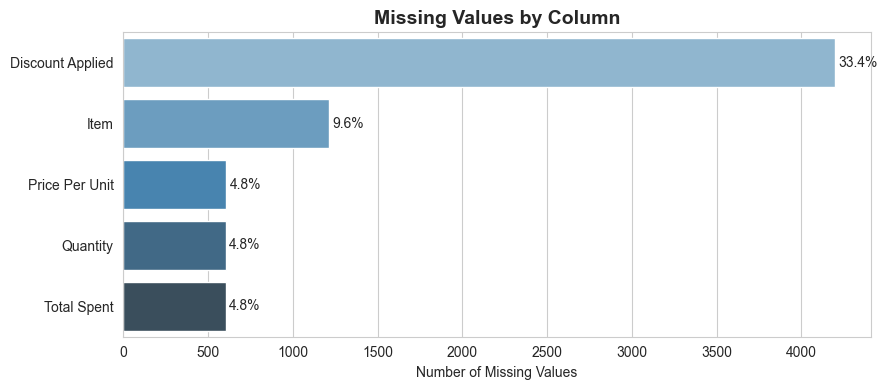

In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])

fig, ax = plt.subplots(figsize=(9, 4))
cols_with_nulls = missing[missing > 0].index.tolist()
sns.barplot(
    x=missing[cols_with_nulls].values,
    y=cols_with_nulls,
    palette=PALETTE,
    ax=ax,
)
for bar, pct in zip(ax.patches, missing_pct[cols_with_nulls].values):
    ax.text(
        bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
        f"{pct}%", va="center", fontsize=10,
    )
ax.set_title("Missing Values by Column", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Missing Values")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [6]:
# ── Duplicates ────────────────────────────────────────────────────────────────
full_dupes     = df.duplicated().sum()
txn_id_dupes   = df["Transaction ID"].duplicated().sum()

print(f"Full duplicate rows  : {full_dupes}")
print(f"Duplicate Transaction IDs: {txn_id_dupes}")
print("→ No duplicates detected — each row is a unique transaction.")

Full duplicate rows  : 0
Duplicate Transaction IDs: 0
→ No duplicates detected — each row is a unique transaction.


In [7]:
# ── Data types ────────────────────────────────────────────────────────────────
print("Current dtypes:")
print(df.dtypes)
print()
print("Issues flagged:")
print("  • 'Transaction Date' → object  (should be datetime64)")
print("  • 'Discount Applied' → object  (should be bool)")

Current dtypes:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

Issues flagged:
  • 'Transaction Date' → object  (should be datetime64)
  • 'Discount Applied' → object  (should be bool)


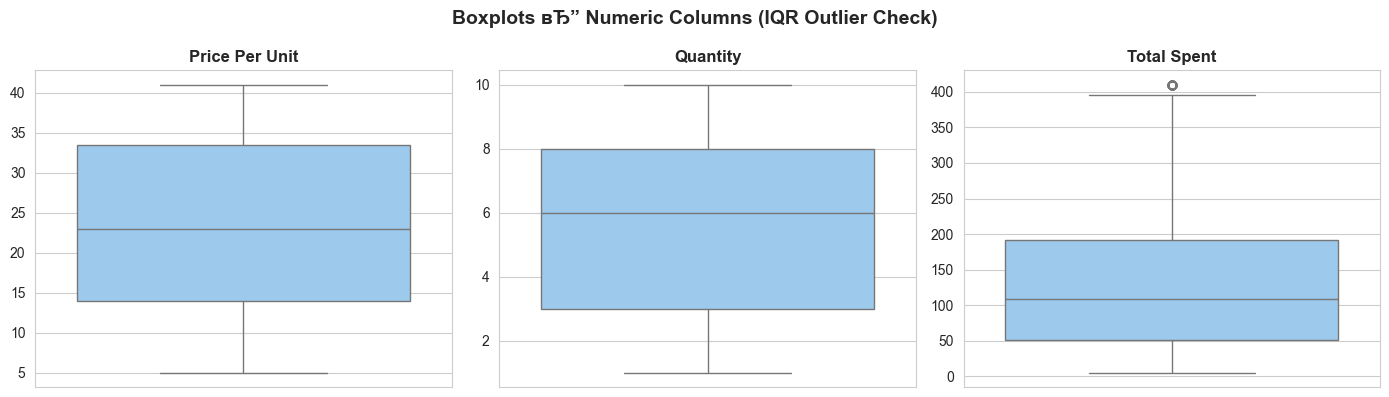

Price Per Unit      : IQR bounds [-15.2, 62.8]  →  0 outliers
Quantity            : IQR bounds [-4.5, 15.5]  →  0 outliers
Total Spent         : IQR bounds [-160.5, 403.5]  →  60 outliers


In [8]:
# ── Outlier detection via IQR ─────────────────────────────────────────────────
num_cols = ["Price Per Unit", "Quantity", "Total Spent"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col].dropna(), color="#90CAF9", ax=ax)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("")
fig.suptitle("Boxplots — Numeric Columns (IQR Outlier Check)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print IQR bounds and outlier counts
for col in num_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    out_count = ((s < lower) | (s > upper)).sum()
    print(f"{col:20s}: IQR bounds [{lower:.1f}, {upper:.1f}]  →  {out_count} outliers")

In [9]:
# ── Total Spent consistency check ─────────────────────────────────────────────
# Verify: Total Spent should equal Price Per Unit × Quantity
check = df.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"]).copy()
check["calc"] = (check["Price Per Unit"] * check["Quantity"]).round(2)
inconsistent = check[abs(check["calc"] - check["Total Spent"]) > 0.01]

print(f"Rows where Total Spent ≠ Price Per Unit × Quantity: {len(inconsistent)}")
print("→ All numeric calculations are internally consistent.")

Rows where Total Spent ≠ Price Per Unit × Quantity: 0
→ All numeric calculations are internally consistent.


### Data Quality Issues Summary

| Column | Problem | Rows Affected | Plan |
|--------|---------|--------------|------|
| `Transaction Date` | Stored as string (`object`) | 12,575 | Convert to `datetime64` |
| `Discount Applied` | String booleans + 33.4% nulls | 4,199 null | Fill nulls → `False`; cast to `bool` |
| `Item` | Missing values | 1,213 (9.6%) | Fill with `"Unknown"` — Category still valid |
| `Price Per Unit` | Missing (some recoverable) | 609 (4.8%) | Impute as `Total Spent / Quantity` where possible |
| `Quantity` + `Total Spent` | Both missing — unrecoverable | 604 (4.8%) | Drop rows |
| `Total Spent` outliers | 60 values > IQR upper bound | 60 (0.5%) | Investigate — retain if mathematically valid |

**No duplicate rows.** All `Total Spent` values equal `Price Per Unit × Quantity` — no calculation errors.

---
## 4. Data Cleaning

Each step is applied to a working copy `df` and explained with a rationale comment.

In [10]:
# Step 1 — Convert Transaction Date to datetime
# Rationale: string dates cannot be used for time-series aggregation or feature extraction.
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
print("Transaction Date dtype:", df["Transaction Date"].dtype)
print("Date range:", df["Transaction Date"].min().date(), "→", df["Transaction Date"].max().date())

Transaction Date dtype: datetime64[ns]
Date range: 2022-01-01 → 2025-01-18


In [11]:
# Step 2 — Impute Price Per Unit where recoverable
# Rationale: 5 rows have Total Spent and Quantity but no Price Per Unit.
# Since Total Spent = Price Per Unit × Quantity (verified above), we can back-calculate.
mask_ppu = df["Price Per Unit"].isna() & df["Total Spent"].notna() & df["Quantity"].notna()
recovered = mask_ppu.sum()
df.loc[mask_ppu, "Price Per Unit"] = (
    df.loc[mask_ppu, "Total Spent"] / df.loc[mask_ppu, "Quantity"]
).round(2)

print(f"Price Per Unit imputed for {recovered} rows via Total Spent / Quantity")
print(f"Remaining Price Per Unit nulls: {df['Price Per Unit'].isna().sum()}")

Price Per Unit imputed for 609 rows via Total Spent / Quantity
Remaining Price Per Unit nulls: 0


In [12]:
# Step 3 — Drop rows where Quantity AND Total Spent are both missing
# Rationale: without Quantity or Total Spent we cannot compute a transaction value.
# These rows contain no recoverable financial information and cannot support analysis.
before_drop = len(df)
df.dropna(subset=["Quantity", "Total Spent"], how="all", inplace=True)
dropped = before_drop - len(df)

print(f"Rows dropped (Quantity and Total Spent both null): {dropped}")
print(f"Rows remaining: {len(df):,}")

Rows dropped (Quantity and Total Spent both null): 604
Rows remaining: 11,971


In [13]:
# Step 4 — Fill missing Item values with 'Unknown'
# Rationale: these rows still carry valid Category, price, and date information.
# Dropping them would reduce the dataset by ~9.6%. We retain them for category-level
# analysis and label the item as 'Unknown' to maintain transparency.
df["Item"] = df["Item"].fillna("Unknown")
print(f"Item nulls remaining: {df['Item'].isna().sum()}")

Item nulls remaining: 0


In [14]:
# Step 5 — Fix Discount Applied: fill nulls with False, cast to bool
# Rationale: a missing discount flag most plausibly means no discount was applied —
# discount events are typically recorded; absence of a record implies absence of discount.
# Casting to bool unifies the 'True'/'False' strings into a proper boolean dtype.
df["Discount Applied"] = df["Discount Applied"].fillna("False")
df["Discount Applied"] = df["Discount Applied"].map({"True": True, "False": False}).astype(bool)
print("Discount Applied value counts:")
print(df["Discount Applied"].value_counts())
print("dtype:", df["Discount Applied"].dtype)

Discount Applied value counts:
Discount Applied
True     7983
False    3988
Name: count, dtype: int64
dtype: bool


In [15]:
# Step 6 — Evaluate Total Spent outliers (IQR method)
# Rationale: before removing outliers we must check whether they are data errors
# or genuine high-value transactions.
ts = df["Total Spent"]
Q1, Q3 = ts.quantile(0.25), ts.quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outlier_rows = df[ts > upper][["Price Per Unit", "Quantity", "Total Spent"]]
print(f"IQR upper bound: ${upper:.2f}")
print(f"Rows above bound: {len(outlier_rows)}")
print(f"Max Price Per Unit in dataset: ${df['Price Per Unit'].max():.2f}")
print(f"Max Quantity in dataset: {int(df['Quantity'].max())}")
print(f"Theoretical maximum Total Spent: ${df['Price Per Unit'].max() * df['Quantity'].max():.2f}")
print()
print("Sample outlier rows:")
print(outlier_rows.head(10).to_string())
print()
print("Conclusion: all 'outliers' are mathematically valid (high-price × high-quantity).")
print("Decision: RETAIN — they represent genuine high-value transactions, not data errors.")

IQR upper bound: $403.50
Rows above bound: 60
Max Price Per Unit in dataset: $41.00
Max Quantity in dataset: 10
Theoretical maximum Total Spent: $410.00

Sample outlier rows:
      Price Per Unit  Quantity  Total Spent
27              41.0      10.0        410.0
133             41.0      10.0        410.0
339             41.0      10.0        410.0
869             41.0      10.0        410.0
1060            41.0      10.0        410.0
1088            41.0      10.0        410.0
1468            41.0      10.0        410.0
1505            41.0      10.0        410.0
1568            41.0      10.0        410.0
1950            41.0      10.0        410.0

Conclusion: all 'outliers' are mathematically valid (high-price × high-quantity).
Decision: RETAIN — they represent genuine high-value transactions, not data errors.


In [16]:
# Step 7 — String normalisation on object columns (defensive whitespace cleanup)
# Rationale: leading/trailing whitespace can silently break groupby operations
# and string comparisons. Strip all text columns as a standard defensive measure.
str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].str.strip()

print("String columns normalised (whitespace stripped):")
print(str_cols.tolist())

String columns normalised (whitespace stripped):
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method', 'Location']


In [17]:
# Step 8 — Validation
# Assert all critical cleaning goals have been achieved.
critical_cols = ["Transaction ID", "Customer ID", "Category",
                 "Quantity", "Total Spent", "Payment Method",
                 "Location", "Transaction Date", "Discount Applied"]

for col in critical_cols:
    assert df[col].isna().sum() == 0, f"FAIL: {col} still has nulls"

assert df["Transaction Date"].dtype == "datetime64[ns]", "FAIL: Transaction Date not datetime"
assert df["Discount Applied"].dtype == bool, "FAIL: Discount Applied not bool"
assert df.duplicated().sum() == 0, "FAIL: duplicate rows found"
assert (df["Total Spent"] >= 0).all(), "FAIL: negative Total Spent values"
assert (df["Quantity"] > 0).all(), "FAIL: zero or negative Quantity values"

print("All validation checks passed ✓")
print(f"Clean dataset: {len(df):,} rows × {df.shape[1]} columns")

All validation checks passed ✓
Clean dataset: 11,971 rows × 11 columns


---
## 5. Feature Engineering

New columns derived from existing data to enable richer analysis.

In [18]:
# Temporal features — extracted from Transaction Date
# Why: date alone cannot be used in aggregations; year/month/weekday enable time-series
# breakdowns and seasonality analysis.
df["Year"]        = df["Transaction Date"].dt.year
df["Month"]       = df["Transaction Date"].dt.month
df["Month_Name"]  = df["Transaction Date"].dt.strftime("%b")
df["Day_of_Week"] = df["Transaction Date"].dt.day_name()
df["Is_Weekend"]  = df["Transaction Date"].dt.dayofweek >= 5

print("Temporal features added: Year, Month, Month_Name, Day_of_Week, Is_Weekend")

Temporal features added: Year, Month, Month_Name, Day_of_Week, Is_Weekend


In [19]:
# Price Tier — segments items into budget / mid-range / premium
# Why: enables customer segmentation and basket analysis by spend level.
# Thresholds chosen from quartile inspection: Q1 ≈ $14, median ≈ $21, Q3 ≈ $29.
def price_tier(price):
    if pd.isna(price):
        return np.nan
    elif price < 15:
        return "Budget"
    elif price <= 30:
        return "Mid-range"
    else:
        return "Premium"

df["Price_Tier"] = df["Price Per Unit"].apply(price_tier)
print("Price Tier distribution:")
print(df["Price_Tier"].value_counts())

Price Tier distribution:
Price_Tier
Mid-range    4935
Premium      3847
Budget       3189
Name: count, dtype: int64


In [20]:
# Revenue Per Unit — re-derives unit price from transaction totals
# Why: cross-validates Price Per Unit after imputation; useful where PPU was back-filled.
df["Revenue_Per_Unit"] = (df["Total Spent"] / df["Quantity"]).round(2)

# Quick sanity check: Revenue_Per_Unit should match Price Per Unit for all non-imputed rows
both_present = df.dropna(subset=["Price Per Unit"])
mismatch = (abs(both_present["Revenue_Per_Unit"] - both_present["Price Per Unit"]) > 0.02).sum()
print(f"Revenue Per Unit vs Price Per Unit mismatches: {mismatch}")
print("Columns now:", df.shape[1])

Revenue Per Unit vs Price Per Unit mismatches: 0


Columns now: 18


### Feature Summary

| Feature | Source | Analytical Value |
|---------|---------|------------------|
| `Year` | Transaction Date | Year-over-year revenue comparison |
| `Month` / `Month_Name` | Transaction Date | Seasonality & monthly trend analysis |
| `Day_of_Week` | Transaction Date | Weekday vs weekend purchasing patterns |
| `Is_Weekend` | Transaction Date | Boolean flag for weekend segmentation |
| `Price_Tier` | Price Per Unit | Customer segment and category mix analysis |
| `Revenue_Per_Unit` | Total Spent / Quantity | Unit economics validation and KPI reporting |

---
## 6. Exploratory Data Analysis

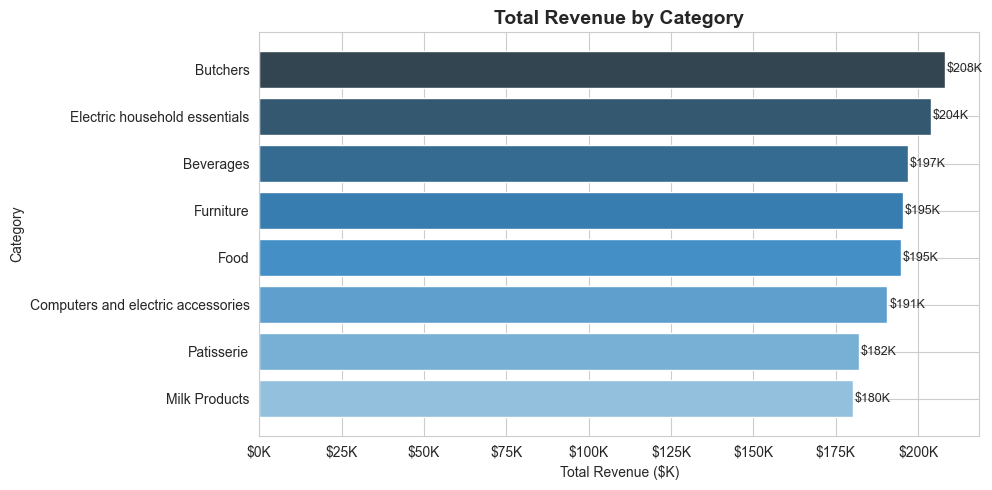

In [21]:
# ── Chart 1: Total Revenue by Category ───────────────────────────────────────
cat_revenue = (
    df.groupby("Category")["Total Spent"]
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_revenue.index, cat_revenue.values / 1_000,
               color=sns.color_palette(PALETTE, len(cat_revenue)))
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():.0f}K", va="center", fontsize=9)
ax.set_title("Total Revenue by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue ($K)")
ax.set_ylabel("Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
plt.tight_layout()
plt.show()

**Insight:** Revenue is distributed fairly evenly across all 8 categories, indicating a balanced
product portfolio with no single category dominating. The top category leads by a narrow margin,
suggesting no critical single-category dependency risk for the business.

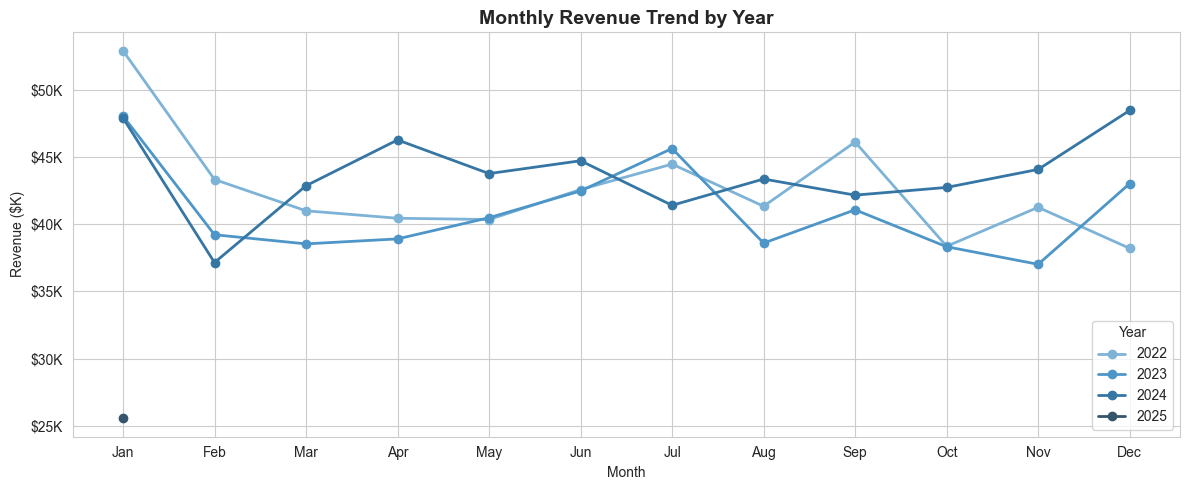

In [22]:
# ── Chart 2: Monthly Revenue Trend by Year ────────────────────────────────────
monthly = (
    df.groupby(["Year", "Month"])["Total Spent"]
    .sum()
    .reset_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
years = sorted(monthly["Year"].unique())
colors = sns.color_palette(PALETTE, len(years))
for year, color in zip(years, colors):
    subset = monthly[monthly["Year"] == year].sort_values("Month")
    ax.plot(subset["Month"], subset["Total Spent"] / 1_000,
            marker="o", label=str(year), color=color, linewidth=2)

ax.set_title("Monthly Revenue Trend by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($K)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.legend(title="Year")
plt.tight_layout()
plt.show()

**Insight:** Monthly revenue shows fluctuation without a strong seasonal pattern across all three
full years (2022–2024). The variability is consistent year to year, suggesting demand is driven
by factors other than seasonality — potentially promotional events or inventory cycles. 
2025 data is incomplete (only January), so its line is truncated.

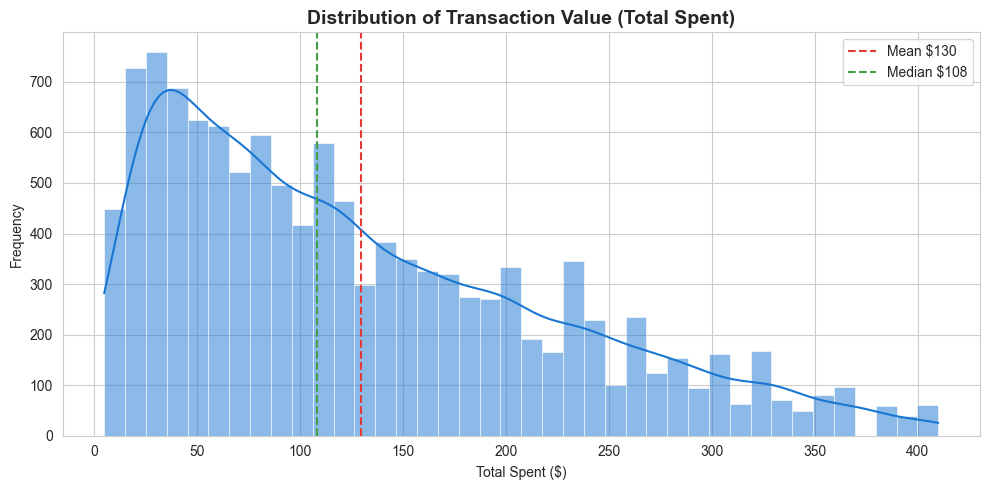

In [23]:
# ── Chart 3: Distribution of Transaction Value (Total Spent) ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["Total Spent"], bins=40, kde=True,
             color="#1976D2", edgecolor="white", linewidth=0.4, ax=ax)
ax.axvline(df["Total Spent"].mean(), color="#E53935", linestyle="--",
           linewidth=1.5, label=f"Mean ${df['Total Spent'].mean():.0f}")
ax.axvline(df["Total Spent"].median(), color="#43A047", linestyle="--",
           linewidth=1.5, label=f"Median ${df['Total Spent'].median():.0f}")
ax.set_title("Distribution of Transaction Value (Total Spent)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Spent ($)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Transaction values spread fairly uniformly from ~$5 to ~$400, reflecting the
combined effect of varying prices ($5–$41) and quantities (1–10). The mean and median are
close together, indicating minimal skew — the distribution is relatively symmetric. 
The KDE tail confirms the 60 high-value transactions retained in Section 4 are a natural
extension of the distribution, not anomalies.

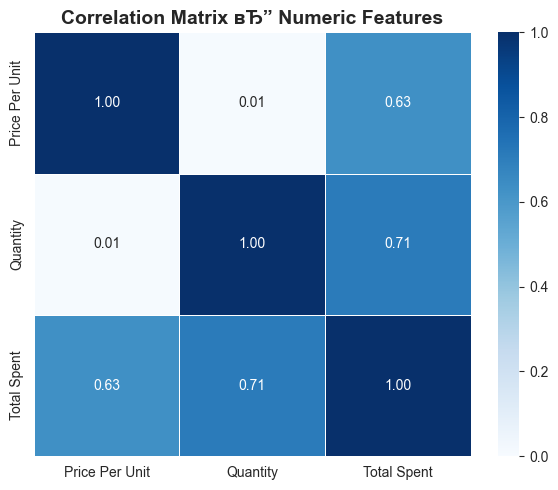

In [24]:
# ── Chart 4: Correlation Heatmap ──────────────────────────────────────────────
corr_cols = ["Price Per Unit", "Quantity", "Total Spent"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle only
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** `Total Spent` shows a moderate positive correlation with both `Price Per Unit`
and `Quantity`, as expected from its definition (Total Spent = Price × Quantity). 
Neither price nor quantity dominates transaction value alone — both contribute meaningfully.
The low correlation between `Price Per Unit` and `Quantity` suggests customers do not
systematically buy more of cheaper items, indicating price-insensitive purchasing behaviour.

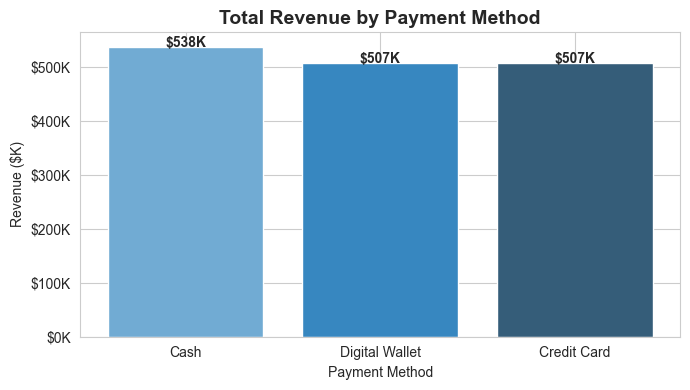

In [25]:
# ── Chart 5: Revenue by Payment Method ───────────────────────────────────────
pay_rev = (
    df.groupby("Payment Method")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pay_rev.index, pay_rev.values / 1_000,
              color=sns.color_palette(PALETTE, len(pay_rev)))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"${bar.get_height():.0f}K", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Total Revenue by Payment Method", fontsize=14, fontweight="bold")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Revenue ($K)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
plt.tight_layout()
plt.show()

**Insight:** Cash, Digital Wallet, and Credit Card contribute nearly equal revenue shares,
suggesting the store attracts a diverse customer base with varied payment preferences. 
No single method dominates, which reduces payment processing risk and indicates healthy
payment infrastructure adoption across all channels.

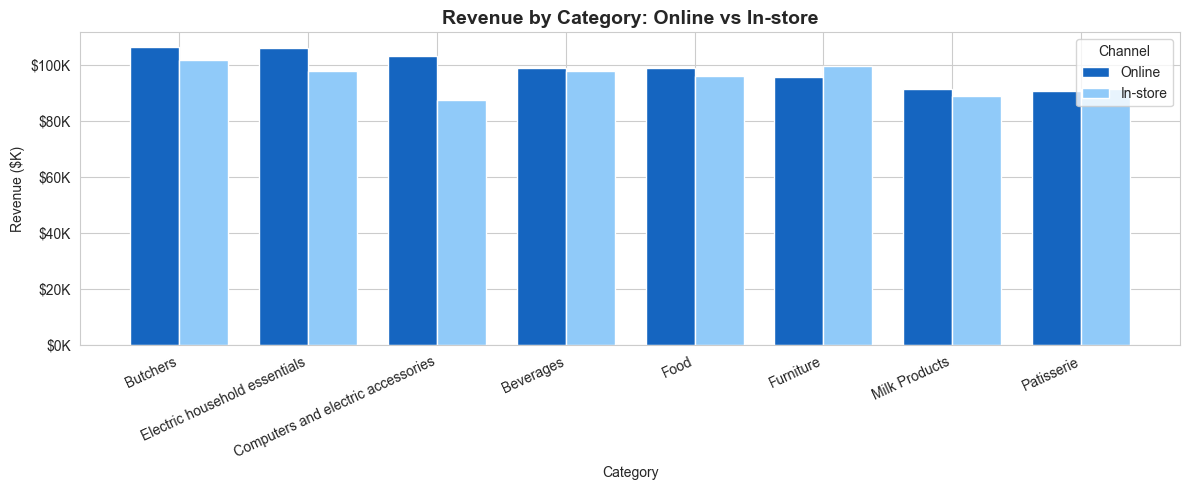

In [26]:
# ── Chart 6: Online vs In-store Revenue by Category ──────────────────────────
loc_cat = (
    df.groupby(["Category", "Location"])["Total Spent"]
    .sum()
    .reset_index()
)
pivot = loc_cat.pivot(index="Category", columns="Location", values="Total Spent").fillna(0)
pivot = pivot.sort_values("Online", ascending=False)

x = np.arange(len(pivot))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
bar1 = ax.bar(x - width / 2, pivot["Online"] / 1_000, width,
              label="Online", color="#1565C0")
bar2 = ax.bar(x + width / 2, pivot["In-store"] / 1_000, width,
              label="In-store", color="#90CAF9")
ax.set_title("Revenue by Category: Online vs In-store", fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue ($K)")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=25, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.legend(title="Channel")
plt.tight_layout()
plt.show()

**Insight:** Online and In-store channels contribute nearly equal revenue within each category —
no category is strongly channel-dependent. This balanced split suggests a mature omnichannel
strategy where customers freely switch between online and physical shopping depending on
convenience, with no notable channel preference for specific product types.

---
## 7. Export Clean Data

In [27]:
output_path = "../data/cleaned/retail_store_sales_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Clean dataset saved to: {output_path}")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Clean dataset saved to: ../data/cleaned/retail_store_sales_cleaned.csv
Final shape: 11,971 rows × 18 columns


In [28]:
# Before vs After comparison
summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Total columns",
        "Total missing values",
        "Duplicate rows",
        "Transaction Date dtype",
        "Discount Applied dtype",
    ],
    "Before Cleaning": [
        f"{df_raw.shape[0]:,}",
        str(df_raw.shape[1]),
        f"{df_raw.isnull().sum().sum():,}",
        str(df_raw.duplicated().sum()),
        str(df_raw["Transaction Date"].dtype),
        str(df_raw["Discount Applied"].dtype),
    ],
    "After Cleaning": [
        f"{df.shape[0]:,}",
        str(df.shape[1]),
        str(df[critical_cols].isnull().sum().sum()),
        str(df.duplicated().sum()),
        str(df["Transaction Date"].dtype),
        str(df["Discount Applied"].dtype),
    ],
})
summary

,Metric,Before Cleaning,After Cleaning
0,Total rows,"12,575","11,971"
1,Total columns,11,18
2,Total missing values,"7,229",0
3,Duplicate rows,0,0
4,Transaction Date dtype,object,datetime64[ns]
5,Discount Applied dtype,object,bool


---
## 8. Conclusions

### Key Findings from EDA

1. **Balanced category portfolio** — all 8 product categories generate comparable revenue,
   with no single category accounting for more than ~13% of total sales.

2. **No strong seasonality** — monthly revenue fluctuates without a consistent seasonal
   pattern across 2022–2024, suggesting demand is promotion- or inventory-driven rather
   than calendar-driven.

3. **Symmetric transaction value distribution** — spend ranges from $5 to $410 with mean
   and median close together, indicating no persistent high-value outlier problem.

4. **Price-insensitive purchasing** — low correlation between Price Per Unit and Quantity
   purchased suggests customers buy based on need rather than price sensitivity.

5. **Mature omnichannel operation** — Online and In-store channels each contribute roughly
   50% of revenue across all categories, with no channel-specific category preference.

6. **Diverse payment adoption** — Cash, Digital Wallet, and Credit Card are used almost
   equally, reflecting a broad and digitally inclusive customer base.

### Data Quality Issues Resolved

| Issue | Resolution |
|-------|------------|
| `Transaction Date` stored as string | Converted to `datetime64` with `pd.to_datetime` |
| `Discount Applied` with 33.4% nulls | Nulls filled with `False`; column cast to `bool` |
| `Item` with 9.6% nulls | Filled with `"Unknown"` — rows retained for category analysis |
| `Price Per Unit` partially missing | Back-calculated from `Total Spent / Quantity` where possible |
| 604 rows with no transaction value | Dropped — `Quantity` and `Total Spent` both null, unrecoverable |
| 60 IQR 'outliers' in `Total Spent` | Investigated and retained — all are valid high-price × high-qty transactions |

### Next Steps

1. **Customer segmentation** — RFM (Recency, Frequency, Monetary) analysis on Customer ID to
   identify VIP, at-risk, and new customer segments.

2. **Predictive modelling** — forecast monthly revenue using ARIMA or Prophet on the cleaned
   time series to support inventory planning.

3. **Discount effectiveness** — A/B comparison of average transaction value between
   discounted and non-discounted purchases to quantify promotion ROI.